**Aspect-Based Sentiment Analysis (ABSA) - LDA & FastText**

*імпорти*

In [138]:
import gensim
from gensim import corpora
from gensim.models import LdaMulticore
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models import FastText
from tqdm import tqdm
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import FastText
import ast
from sklearn.cluster import KMeans


***1. LDA***

In [158]:
def build_lda_model(df, num_topics, filter_extremes=True, no_below=5, no_above=0.5):
    
    # створення словника
    id2word = corpora.Dictionary(df['token'])
    
    if filter_extremes:
        id2word.filter_extremes(no_below=no_below, no_above=no_above) # - фільтрація слів 

    corpus = [id2word.doc2bow(text) for text in df['token']]
    
    # побудова LDA
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        iterations=400
    )
    
    return lda_model, corpus, id2word


***2. FastText***

In [140]:
def build_fasttext_model(df, vector_size, window, min_count, workers, sg):

    # Формуємо корпус
    data_words = df['token'].values.tolist()

    # Навчання моделі
    fasttext_model = FastText(
        sentences=data_words,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=sg  # 1 = skip-gram, 0 = CBOW
    )

    return fasttext_model


In [141]:
def get_similarity(model, words, aspect):
    sim = 0
    count = 0
    for w in words:
        try:
            sim += model.wv.similarity(w, aspect)
            count += 1
        except KeyError:
            pass
    return sim / count if count > 0 else 0

***3. LDA + FastTxt***

*отримyємо слов6а з LDA тем*

In [142]:
def get_lda_topics_words(lda_model, num_topics=5, topn=10):
    topics = []
    for i in range(num_topics):
        words = [w for w,_ in lda_model.show_topic(i, topn=topn)]
        topics.append(words)
    return topics

*обчислення близькості слів теми до аспектів FastText*

In [143]:
def topic_aspect_similarity(lda_topics, fasttext_model, aspects):
    similarities = []

    for topic_words in lda_topics:
        topic_sim_row = []

        for asp in aspects:
            # відбираємо тільки слова наявні у FastText 
            valid_words = [w for w in topic_words if w in fasttext_model.wv]

            if len(valid_words) == 0 or asp not in fasttext_model.wv:
                topic_sim_row.append(0)
                continue

            # n_similarity порівнює списки слів семантично
            sim = fasttext_model.wv.n_similarity(valid_words, [asp])
            topic_sim_row.append(sim)

        similarities.append(topic_sim_row)

    df_sim = pd.DataFrame(similarities, columns=aspects)
    df_sim.index = [f"Topic {i}" for i in range(len(lda_topics))]
    return df_sim

***4. Візалізація***

*візyалізацнія LDA*

In [144]:
def assign_topics_to_reviews(lda_model, corpus, topic_labels):
    topic_list = []
    for doc in corpus:
        topic_probs = lda_model.get_document_topics(doc)
        best_topic = max(topic_probs, key=lambda x: x[1])[0]
        topic_list.append(topic_labels[best_topic])
    return topic_list

In [145]:
def lda(lda_model, corpus, id2word):
    for idx, topic in lda_model.print_topics(-1):
        print(f"Тема {idx+1}: {topic}\n")
    
    pyLDAvis.enable_notebook()
    vis = gensimvis.prepare(lda_model, corpus, id2word)
    display(vis)

*візyалізацнія FastTеxt*

In [146]:
def fasttext(df, model, aspects):
    tqdm.pandas()
    for aspect in aspects:
        df[aspect] = df['token'].progress_map(
            lambda text: get_similarity(model, text, aspect)
        )
    return df

*візyалізацнія LDA + FastTеxt*

In [147]:
def plot_heatmap(df_sim):
    plt.figure(figsize=(8,6))
    sns.heatmap(df_sim, annot=True, cmap="YlGnBu", fmt=".3f")
    plt.title("LDA Topic ↔ FastText Aspect Similarity")
    plt.show()

***5. Виклик***

In [148]:
def main(df):
    # LDA
    lda_model, corpus, id2word = build_lda_model(df, num_topics=3)
    
    # FastText
    fasttext_model = build_fasttext_model(
        df,
        vector_size=100,
        window=5,
        min_count=5,
        workers=4,
        sg=1
    )

    aspects = ["food", "service", "place"]

    # LDA + FastText
    lda_topics = get_lda_topics_words(lda_model, num_topics=3, topn=10)
    df_sim = topic_aspect_similarity(lda_topics, fasttext_model, aspects)

    # візyалізацнія LDA
    lda(lda_model, corpus, id2word)

    # візyалізацнія FastText
    df = fasttext(df,fasttext_model, aspects)


    # візyалізацнія LDA + FastText
    plot_heatmap(df_sim)
    
    return lda_model, fasttext_model, df_sim


Тема 1: 0.026*"good" + 0.023*"food" + 0.017*"order" + 0.014*"service" + 0.013*"place" + 0.011*"chicken" + 0.008*"n't" + 0.008*"taste" + 0.007*"also" + 0.007*"try"

Тема 2: 0.032*"good" + 0.026*"food" + 0.020*"place" + 0.015*"..." + 0.013*"service" + 0.013*"order" + 0.013*"taste" + 0.010*"chicken" + 0.009*"'s" + 0.009*"go"

Тема 3: 0.029*"place" + 0.029*"good" + 0.028*"food" + 0.013*"order" + 0.013*"taste" + 0.011*"service" + 0.011*"great" + 0.009*"ambience" + 0.008*"nice" + 0.008*"really"



PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.010791  0.015316       1        1  40.422781
1     -0.012623 -0.014538       2        1  37.071512
0      0.023414 -0.000779       3        1  22.505707, topic_info=        Term         Freq        Total Category  logprob  loglift
66       ...  1729.000000  1729.000000  Default  30.0000  30.0000
510  chicken  1940.000000  1940.000000  Default  29.0000  29.0000
48     order  3301.000000  3301.000000  Default  28.0000  28.0000
22   service  2927.000000  2927.000000  Default  27.0000  27.0000
8       good  7075.000000  7075.000000  Default  26.0000  26.0000
..       ...          ...          ...      ...      ...      ...
139       go   270.658749  1690.556459   Topic3  -5.2981  -0.3406
62      nice   250.109140  1410.422131   Topic3  -5.3771  -0.2383
269      bad   213.615250   977.460890   Topic3  -5.5348  -0.0294
107    staff   187.804733   882.607091   Topic3  -5.6636  -0.0561
28     great   197.923085  1848.332251   Topic3  -5.6111  -0.7428

[275 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
265       1  0.317924       's
265       2  0.492025       's
265       3  0.189871       's
250       1  0.222500       ..
250       2  0.629091       ..
...     ...       ...      ...
2074      2  0.811904  zafrani
2074      3  0.162381  zafrani
3619      1  0.282712        ‘
3619      2  0.094237        ‘
3619      3  0.659661        ‘

[504 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 1])

100%|██████████| 9955/9955 [00:02<00:00, 3801.57it/s]


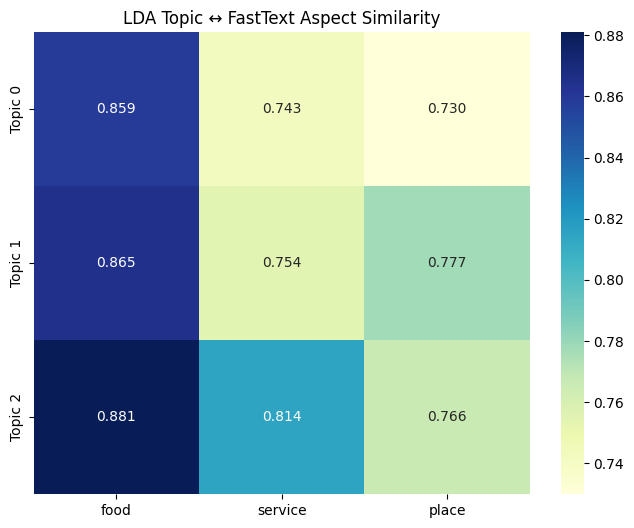

In [159]:
result = pd.read_csv("TextCleaner.csv")

#result["lemma"] = result["lemmas"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
#result["lemma"] = result["lemma"].apply(lambda lst: [w for phrase in lst for w in phrase.split()])

result["token"] = result["tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
#result["token"] = result["token"].apply(lambda lst: [w for phrase in lst for w in phrase.split()])

bigram = gensim.models.Phrases(result["token"], min_count=5, threshold=10)
trigram = gensim.models.Phrases(bigram[result["token"]], threshold=10)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

result["token"] = result["token"].apply(lambda x: trigram_mod[bigram_mod[x]])


lda_model, fasttext_model, df_sim = main(result)
result.to_csv("LDA-FastText.csv", index=False, encoding='utf-8-sig')

In [160]:
result.head(40)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514,Review_cleaned,Review_corrected,language,tokens,aspects,token,food,service,place
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0,"The ambience was good, food was quite good . h...",The ambience was good food was quite good . ha...,en,"['ambience', 'good', 'food', 'quite', 'good', ...","['good food', 'saturday lunch', 'cost effectiv...","[ambience, good, food, quite, good, saturday, ...",0.696127,0.609465,0.687915
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN,Ambience is too good for a pleasant evening. S...,Ambience is too good for a pleasant evening Se...,en,"['ambience', 'good', 'pleasant', 'even', 'serv...","['good pleasant', 'service prompt', 'prompt fo...","[ambience, good, pleasant, even, service_promp...",0.753249,0.719527,0.659636
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN,A must try.. great food great ambience. Thnx f...,A must try great food great ambience the for t...,en,"['must', 'try', 'great', 'food', 'great', 'amb...","['great food', 'food great', 'great ambience',...","[must_try, great, food, great, ambience, servi...",0.683701,0.606101,0.624306
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN,Soumen das and Arun was a great guy. Only beca...,some was and run was a great guys Only because...,en,"['run', 'great', 'guy', 'behavior', 'sincerely...","['great guy', 'good food']","[run, great, guy, behavior, sincerely, good, f...",0.703182,0.626382,0.695064
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN,Food is good.we ordered Kodi drumsticks and ba...,Food is goodbye ordered jodi drumsticks and ba...,en,"['food', 'goodbye', 'order', 'jodi', 'drumstic...","['jodi drumstick', 'good thanks']","[food, goodbye, order, jodi, drumstick, basket...",0.678978,0.584634,0.577936
5,Beyond Flavours,Nagabhavani K,"Ambiance is good, service is good, food is aPr...",5,1 Review,5/24/2019 15:22,0,NaN,"Ambiance is good, service is good, food is aPr...",Ambiance is good service is good food is aPrad...,en,"['ambiance', 'good', 'service', 'good', 'food'...","['good service', 'service good', 'good food', ...","[ambiance, good, service, good, food, apradeec...",0.757773,0.683663,0.660158
6,Beyond Flavours,Jamuna Bhuwalka,"Its a very nice place, ambience is different, ...",5,1 Review,5/24/2019 1:02,0,NaN,"Its a very nice place, ambience is different, ...",Its a very nice place ambience is different al...,en,"['nice', 'place', 'ambience', 'different', 'fo...","['nice place', 'ambience different', 'differen...","[nice, place, ambience, different, food, order...",0.708388,0.635907,0.647158
7,Beyond Flavours,Sandhya S,Well after reading so many reviews finally vis...,4,1 Review,5/23/2019 15:01,0,NaN,Well after reading so many reviews finally vis...,Well after reading so many reviews finally vis...,en,"['well', 'read', 'many', 'review', 'finally', ...","['many review', 'corn nice', 'nice tara', 'tar...","[well, read, many, review, finally, visit, pla...",0.661784,0.570536,0.621324
8,Beyond Flavours,Akash Thorat,"Excellent food , specially if you like spicy f...",5,"1 Review , 1 Follower",5/22/2019 23:12,0,NaN,"Excellent food , specially if you like spicy f...","Excellent food , specially if you like spicy f...",en,"['excellent', 'food', 'specially', 'like', 'sp...","['excellent food', 'courteous staff', 'pradeep...","[excellent, food, specially, like, spicy, food...",0.713215,0.659825,0.650540
9,Beyond Flavours,Smarak Patnaik,Came for the birthday treat of a close friend....,5,"1 Review , 1 Follower",5/22/2019 22:37,0,NaN,Came for the birthday treat of a c